In [1]:
!pip install pandas scipy

import pandas as pd
from scipy.io import arff
import numpy as np
import os;

# Define the path to your ARFF file
file_path = os.path.join('/kaggle/input/datasets/tarekyahia/credit-g', 'dataset_31_credit-g.arff')

# 1. Load the ARFF data
df, meta = arff.loadarff(file_path)

# 2. Convert the structured array to a Pandas DataFrame
data = pd.DataFrame(df)

object_cols = data.select_dtypes(include=['object']).columns
for col in object_cols:
    # Use .apply() with a lambda function for robust decoding.
    # It checks if the value is a byte string (isinstance(x, bytes)) and decodes it using 'utf-8'.
    # Otherwise, it returns the value as is.
    data[col] = data[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)

In [2]:
from sklearn.model_selection import train_test_split
X = data.drop('class', axis=1)
y = data['class'].map({'bad': 1, 'good': 0})

# Perform a stratified train-test split to ensure both sets have the same fraud ratio (0.17%)
# Using 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [3]:
# Numerical features: columns with numeric dtype
numerical_features = X_train.select_dtypes(include=['float64']).columns.tolist()

# Categorical features: columns with object or category dtype
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features ({len(numerical_features)}): {numerical_features}\n')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

Numerical features (7): ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']

Categorical features (13): ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Numerical pipeline: only scaling
numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical pipeline: only one-hot encoding
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore',drop='first'))
])

# Combine pipelines into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])


In [5]:
from sklearn.metrics import (
    precision_recall_curve,
    auc,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
 

def evaluate_model(y_true, y_pred_proba, y_pred_class, model_name, method):
    """Calculates and returns key metrics, including AUPRC."""

    # Calculate Precision-Recall AUC (AUPRC) - Recommended for imbalance
    precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall, precision)

    # Calculate other key metrics
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    recall = recall_score(y_true, y_pred_class)
    precision = precision_score(y_true, y_pred_class)
    f1 = f1_score(y_true, y_pred_class)

    # Calculate Confusion Matrix for review
    cm = confusion_matrix(y_true, y_pred_class)
    print("confusion_matrix:\n",cm)
    print("classification_report:\n",classification_report(y_true, y_pred_class))

    tn, fp, fn, tp = cm.ravel()

    results = {
        'Model': model_name,
        'Method': method,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'Recall (Fraud)': recall,
        'Precision (Fraud)': precision,
        'F1-Score': f1,
        'True Positives (TP)': tp,
        'False Negatives (FN)': fn  # Missed Fraud - critical risk
    }
    return results
final_results = []

In [6]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy='minority', random_state=42)

LR - CW

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFE

lr_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'))),
    ('classifier', LogisticRegression(
        random_state=42,
        penalty='l1',
        solver='liblinear',
        class_weight='balanced',
        max_iter=1000,
        C=0.1,
    ))
])

lr_cw.fit(X_train, y_train)
y_pred_proba_cw = lr_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = lr_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "LR","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[151  59]
 [ 23  67]]
classification_report:
               precision    recall  f1-score   support

           0       0.87      0.72      0.79       210
           1       0.53      0.74      0.62        90

    accuracy                           0.73       300
   macro avg       0.70      0.73      0.70       300
weighted avg       0.77      0.73      0.74       300

Model                         LR
Method                        CW
PR-AUC                  0.628357
ROC-AUC                 0.774021
Recall (Fraud)          0.744444
Precision (Fraud)       0.531746
F1-Score                 0.62037
True Positives (TP)           67
False Negatives (FN)          23
dtype: object


In [8]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_cw.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_cw.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                              Feature  Coefficient
12                           cat__savings_status_<100     0.438439
0                                       num__duration     0.342441
1                             cat__checking_status_<0     0.244860
16                                 cat__employment_<1     0.189542
22                                  cat__housing_rent     0.167574
23                            cat__foreign_worker_yes     0.145180
20          cat__property_magnitude_no known property     0.138495
8                                cat__purpose_new car     0.007546
17                         cat__employment_unemployed     0.000000
14               cat__savings_status_no known savings     0.000000
6                   cat__credit_history_existing paid     0.000000
7                              cat__purpose_education     0.000000
5              cat__credit_history_delayed previously     0.000000
2                          cat__checking_status_>=200     0.00

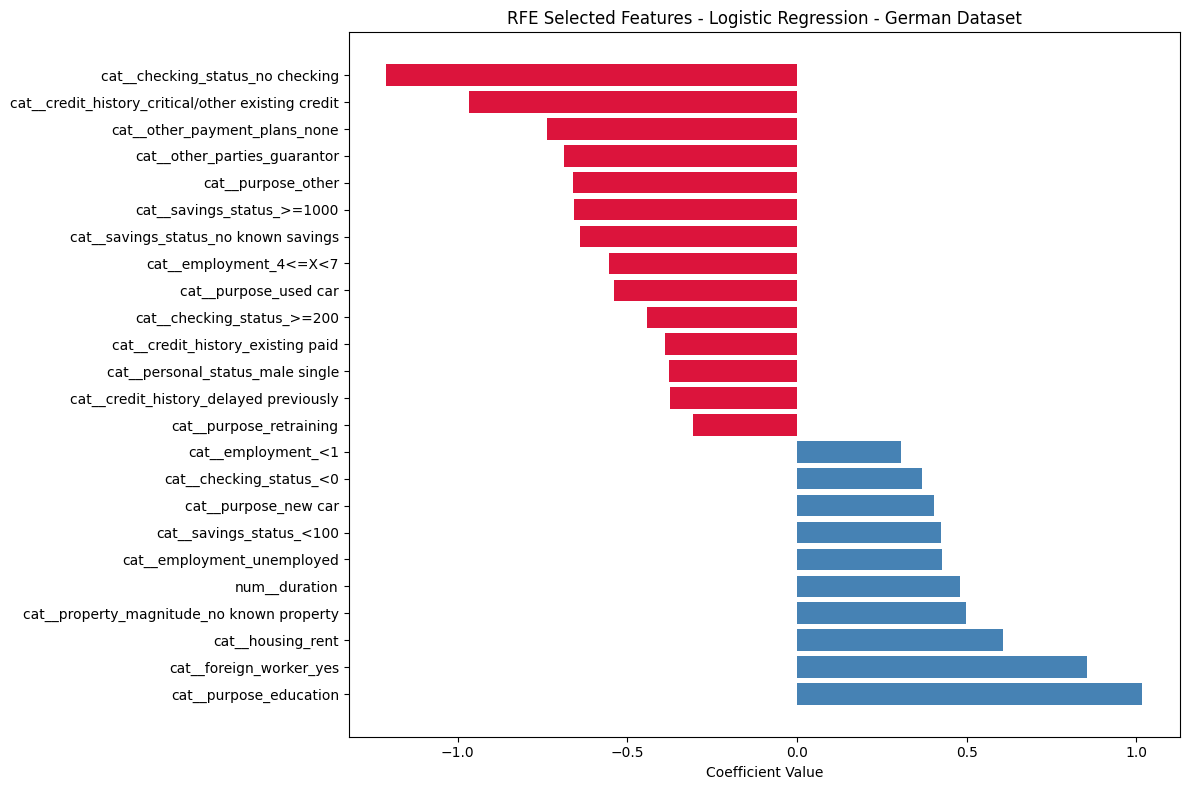

In [9]:
feature_names = lr_cw.named_steps['preprocessor'].get_feature_names_out()
selector = lr_cw.named_steps['selector']
selected_mask = selector.support_
selected_features = feature_names[selected_mask]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Get coefficients
coefs = selector.estimator_.coef_[0]


# Use absolute value for ranking
#importance = np.abs(coefs)
importance = coefs

# Sort
indices = np.argsort(importance)

sorted_importance = importance[indices]
sorted_features = np.array(selected_features)[indices]

# Soft professional color
#colors = cm.GnBu(np.linspace(0.3, 0.8, len(indices)))
colors = ['#4682B4' if c > 0 else '#DC143C' for c in sorted_importance]

plt.figure(figsize=(12, 8))
plt.barh(range(len(indices)), sorted_importance, color=colors)

plt.yticks(range(len(indices)), sorted_features)
plt.xlabel("Coefficient Value")
plt.title("RFE Selected Features - Logistic Regression - German Dataset")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

LR - SMOTE

In [10]:
from imblearn.pipeline import Pipeline as ImbPipeline

lr_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('selector', RFE(estimator=LogisticRegression(solver='liblinear'), n_features_to_select=10)),
    ('classifier', LogisticRegression(
        random_state=42,
        C=0.001,
        max_iter=1000,
        solver='liblinear',
        penalty='l2',
        class_weight=None,
    ))
])

# Train on the SMOTE-resampled training data
lr_smote.fit(X_train, y_train)
y_pred_proba_smote = lr_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = lr_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "LR", "SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[140  70]
 [ 34  56]]
classification_report:
               precision    recall  f1-score   support

           0       0.80      0.67      0.73       210
           1       0.44      0.62      0.52        90

    accuracy                           0.65       300
   macro avg       0.62      0.64      0.62       300
weighted avg       0.70      0.65      0.67       300

Model                         LR
Method                     SMOTE
PR-AUC                  0.492302
ROC-AUC                 0.720741
Recall (Fraud)          0.622222
Precision (Fraud)       0.444444
F1-Score                0.518519
True Positives (TP)           56
False Negatives (FN)          34
dtype: object


In [11]:
# 1. Get the original feature names from the preprocessor
# These are the names of the 30 columns before RFE cut them
original_names = lr_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the "Support Mask" from the RFE selector
# This is a list of True/False values (True = kept, False = dropped)
mask = lr_smote.named_steps['selector'].get_support()

# 3. Apply the mask to the original names to get the 10 selected features
selected_names = original_names[mask]

# 4. Grab the coefficients from the final classifier
# These 10 coefficients match the 10 selected_names
coefficients = lr_smote.named_steps['classifier'].coef_[0]

# 5. Combine into a readable DataFrame or Series
feature_importance = pd.DataFrame({
    'Feature': selected_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                                             Feature  Coefficient
4                           cat__savings_status_<100     0.050041
9                            cat__foreign_worker_yes     0.013391
3                             cat__purpose_education     0.011007
8                    cat__other_payment_plans_stores    -0.001203
0                         cat__checking_status_>=200    -0.004586
5                         cat__savings_status_>=1000    -0.010401
6                             cat__employment_4<=X<7    -0.017396
7                      cat__other_payment_plans_none    -0.020554
2  cat__credit_history_critical/other existing cr...    -0.043167
1                   cat__checking_status_no checking    -0.082756


RF - CW

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

rf_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs = -1,
        class_weight='balanced',
        criterion='entropy',
        max_depth=10,
        max_features='sqrt',
        min_samples_split=2
    ))
])

rf_cw.fit(X_train, y_train)
y_pred_proba_cw = rf_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = rf_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "RF","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[185  25]
 [ 47  43]]
classification_report:
               precision    recall  f1-score   support

           0       0.80      0.88      0.84       210
           1       0.63      0.48      0.54        90

    accuracy                           0.76       300
   macro avg       0.71      0.68      0.69       300
weighted avg       0.75      0.76      0.75       300

Model                         RF
Method                        CW
PR-AUC                  0.563475
ROC-AUC                 0.770529
Recall (Fraud)          0.477778
Precision (Fraud)       0.632353
F1-Score                0.544304
True Positives (TP)           43
False Negatives (FN)          47
dtype: object


In [13]:
# 1. Get original names from preprocessor
feature_names = rf_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_cw.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 11 out of 48 features.
num__credit_amount                                    0.220918
num__age                                              0.182614
num__duration                                         0.155778
cat__checking_status_no checking                      0.098218
num__installment_commitment                           0.067499
num__residence_since                                  0.065159
cat__other_payment_plans_none                         0.046993
cat__credit_history_critical/other existing credit    0.046327
cat__savings_status_<100                              0.041931
cat__checking_status_<0                               0.038497
dtype: float64


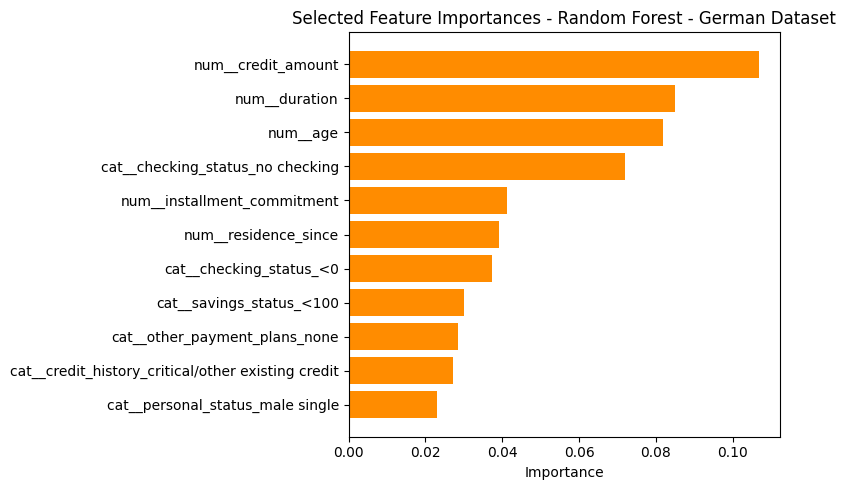

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#FF8C00'

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances - Random Forest - German Dataset")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

RF - SMOTE

In [15]:
rf_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
        threshold="mean"
    )),
    ('classifier', RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        max_features='log2',
        max_depth=20,
        criterion='entropy',
        n_jobs=-1,
        class_weight=None
    ))
])

# Train on the SMOTE-resampled training data
rf_smote.fit(X_train, y_train)
y_pred_proba_smote = rf_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = rf_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "RF","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[181  29]
 [ 51  39]]
classification_report:
               precision    recall  f1-score   support

           0       0.78      0.86      0.82       210
           1       0.57      0.43      0.49        90

    accuracy                           0.73       300
   macro avg       0.68      0.65      0.66       300
weighted avg       0.72      0.73      0.72       300

Model                         RF
Method                     SMOTE
PR-AUC                  0.535209
ROC-AUC                  0.74791
Recall (Fraud)          0.433333
Precision (Fraud)       0.573529
F1-Score                0.493671
True Positives (TP)           39
False Negatives (FN)          51
dtype: object


In [16]:
# 1. Get original names from preprocessor
feature_names = rf_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the mask from the selection step
selector = rf_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Filter names and get importance scores from the FINAL classifier
selected_names = feature_names[support_mask]
importances = rf_smote.named_steps['classifier'].feature_importances_

# 4. Create the Series
rf_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Selected {len(selected_names)} out of {len(feature_names)} features.")
print(rf_importance_series.head(10))

Selected 14 out of 48 features.
num__credit_amount                                    0.146681
num__age                                              0.121511
num__duration                                         0.120234
cat__checking_status_no checking                      0.109602
cat__checking_status_<0                               0.069998
num__installment_commitment                           0.068876
cat__savings_status_<100                              0.063688
num__residence_since                                  0.059205
cat__other_payment_plans_none                         0.046743
cat__credit_history_critical/other existing credit    0.043236
dtype: float64


XGB - CW

In [17]:
!pip install xgboost

In [18]:
from sklearn.feature_selection import SelectFromModel
import xgboost as xgb
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1] 
xgb_cw = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

xgb_cw.fit(X_train, y_train)
y_pred_proba_cw = xgb_cw.predict_proba(X_test)[:, 1]
y_pred_class_cw = xgb_cw.predict(X_test)

metrics_cw = evaluate_model(y_test, y_pred_proba_cw, y_pred_class_cw, "XGB","CW")
final_results.append(metrics_cw)
print(pd.Series(metrics_cw))

confusion_matrix:
 [[155  55]
 [ 33  57]]
classification_report:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78       210
           1       0.51      0.63      0.56        90

    accuracy                           0.71       300
   macro avg       0.67      0.69      0.67       300
weighted avg       0.73      0.71      0.71       300

Model                        XGB
Method                        CW
PR-AUC                  0.544783
ROC-AUC                 0.759259
Recall (Fraud)          0.633333
Precision (Fraud)       0.508929
F1-Score                0.564356
True Positives (TP)           57
False Negatives (FN)          33
dtype: object


In [19]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_cw.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_cw.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_cw.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 24 out of 48
cat__checking_status_no checking                      0.192338
cat__property_magnitude_real estate                   0.070300
cat__property_magnitude_no known property             0.054134
cat__savings_status_<100                              0.050854
cat__other_payment_plans_none                         0.049559
cat__credit_history_delayed previously                0.042844
cat__credit_history_critical/other existing credit    0.042366
cat__purpose_radio/tv                                 0.040684
cat__personal_status_male single                      0.039316
cat__purpose_education                                0.039302
dtype: float32


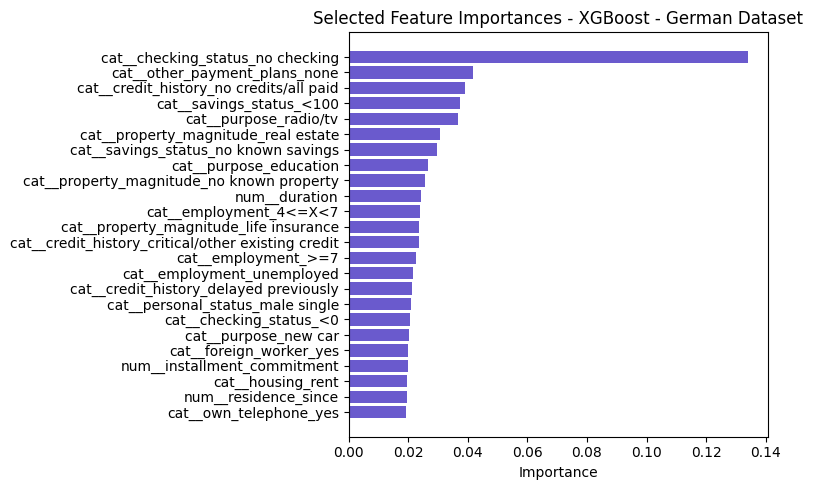

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# Get feature importances from the feature selection model
importances = selector.estimator_.feature_importances_

# Keep only selected ones
selected_importances = importances[support_mask]

# Sort them
indices = np.argsort(selected_importances)

# Use a pastel colormap
#colors = cm.Pastel1(np.linspace(0, 1, len(indices)))
colors = '#6A5ACD'


plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), selected_importances[indices],color=colors)
plt.yticks(range(len(indices)), selected_names[indices])
plt.title("Selected Feature Importances - XGBoost - German Dataset")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

XGB - SMOTE

In [21]:
xgb_smote = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('feature_selection', SelectFromModel(
        xgb.XGBClassifier(n_estimators=100, random_state=42), 
        threshold="median" # Keeps the top 50% of features
    )),
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        scale_pos_weight=None,
        max_depth=3,
        gamma=0,
        learning_rate=0.1,
        n_estimators=300,
    ))
])

# Train on the SMOTE-resampled training data
xgb_smote.fit(X_train, y_train)
y_pred_proba_smote = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_class_smote = xgb_smote.predict(X_test)

metrics_smote = evaluate_model(y_test, y_pred_proba_smote, y_pred_class_smote, "XGBoost","SMOTE")
final_results.append(metrics_smote)
print(pd.Series(metrics_smote))

confusion_matrix:
 [[171  39]
 [ 47  43]]
classification_report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.80       210
           1       0.52      0.48      0.50        90

    accuracy                           0.71       300
   macro avg       0.65      0.65      0.65       300
weighted avg       0.71      0.71      0.71       300

Model                    XGBoost
Method                     SMOTE
PR-AUC                  0.519624
ROC-AUC                 0.756508
Recall (Fraud)          0.477778
Precision (Fraud)        0.52439
F1-Score                     0.5
True Positives (TP)           43
False Negatives (FN)          47
dtype: object


In [22]:
# 1. Get original feature names from the preprocessor
feature_names = xgb_smote.named_steps['preprocessor'].get_feature_names_out()

# 2. Get the selection mask
selector = xgb_smote.named_steps['feature_selection']
support_mask = selector.get_support()

# 3. Apply mask to names
selected_names = feature_names[support_mask]

# 4. Map back to the FINAL classifier's feature importances
importances = xgb_smote.named_steps['classifier'].feature_importances_
xgb_importance_series = pd.Series(importances, index=selected_names).sort_values(ascending=False)

print(f"Features selected: {len(selected_names)} out of {len(feature_names)}")
print(xgb_importance_series.head(10))

Features selected: 24 out of 48
cat__checking_status_no checking                      0.288581
cat__savings_status_<100                              0.073601
cat__credit_history_critical/other existing credit    0.060905
cat__checking_status_<0                               0.049456
cat__property_magnitude_real estate                   0.044634
cat__other_payment_plans_none                         0.044194
cat__purpose_new car                                  0.039383
cat__purpose_education                                0.038728
cat__checking_status_>=200                            0.038183
cat__personal_status_male single                      0.029874
dtype: float32


In [23]:
results_df = pd.DataFrame(final_results)
print(results_df[[
    'Model',
    'Method',
    'PR-AUC',
    'ROC-AUC',
    'Recall (Fraud)',
    'Precision (Fraud)',
    'F1-Score',
    'True Positives (TP)',
    'False Negatives (FN)'
]])

     Model Method    PR-AUC   ROC-AUC  Recall (Fraud)  Precision (Fraud)  \
0       LR     CW  0.628357  0.774021        0.744444           0.531746   
1       LR  SMOTE  0.492302  0.720741        0.622222           0.444444   
2       RF     CW  0.563475  0.770529        0.477778           0.632353   
3       RF  SMOTE  0.535209  0.747910        0.433333           0.573529   
4      XGB     CW  0.544783  0.759259        0.633333           0.508929   
5  XGBoost  SMOTE  0.519624  0.756508        0.477778           0.524390   

   F1-Score  True Positives (TP)  False Negatives (FN)  
0  0.620370                   67                    23  
1  0.518519                   56                    34  
2  0.544304                   43                    47  
3  0.493671                   39                    51  
4  0.564356                   57                    33  
5  0.500000                   43                    47  


Generating SHAP for logistic Regression...


  0%|          | 0/100 [00:00<?, ?it/s]

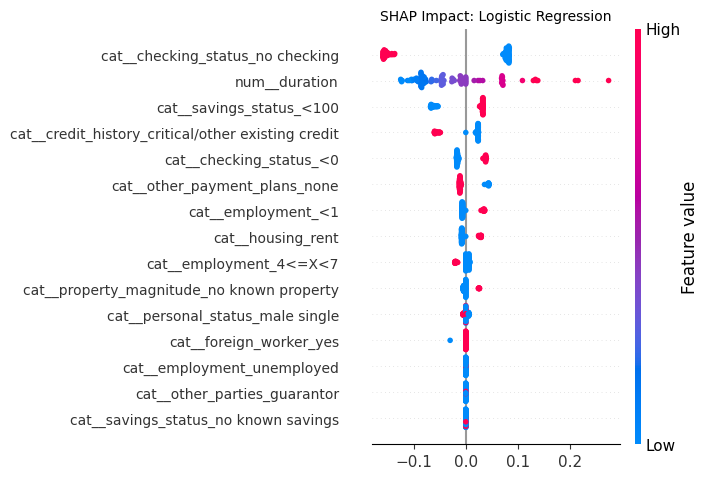

In [53]:
# --- LOGISTIC REGRESSION SHAP ---
model_name = 'logistic Regression' # Or 'lr_smote'
pipeline = lr_cw 

print(f"Generating SHAP for {model_name}...")

# 1. Transform data through preprocessor and RFE selector
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['selector'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['selector'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8,5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Logistic Regression", fontsize=10)
plt.show()

Generating SHAP for rf_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

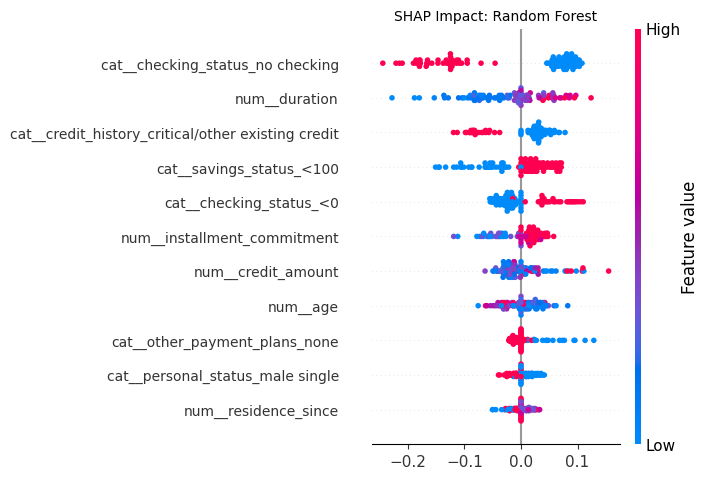

In [52]:
# --- RANDOM FOREST SHAP ---
model_name = 'rf_cw' # Or 'rf_smote'
pipeline = rf_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=15, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: Random Forest", fontsize=10)
plt.show()

Generating SHAP for xgb_cw...


  0%|          | 0/100 [00:00<?, ?it/s]

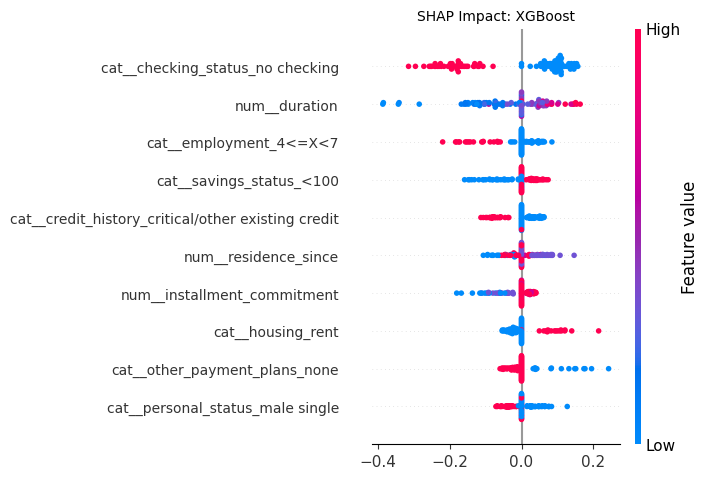

In [54]:
# --- XGBOOST SHAP ---
model_name = 'xgb_cw' # Or 'xgb_smote'
pipeline = xgb_cw

print(f"Generating SHAP for {model_name}...")

# 1. Transform data
X_pre = pipeline.named_steps['preprocessor'].transform(X_test)
X_final = pipeline.named_steps['feature_selection'].transform(X_pre)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()[pipeline.named_steps['feature_selection'].get_support()]

# 2. SHAP KernelExplainer
explainer = shap.KernelExplainer(lambda x: pipeline.named_steps['classifier'].predict_proba(x)[:, 1], X_final[:20])
shap_values = explainer.shap_values(X_final[:100])

# 3. Plotting
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, X_final[:100], feature_names=feature_names, max_display=10, plot_size=(8, 5), show=False)
plt.xlabel('')
plt.yticks(fontsize=10)
plt.title(f"SHAP Impact: XGBoost", fontsize=10)
plt.show()